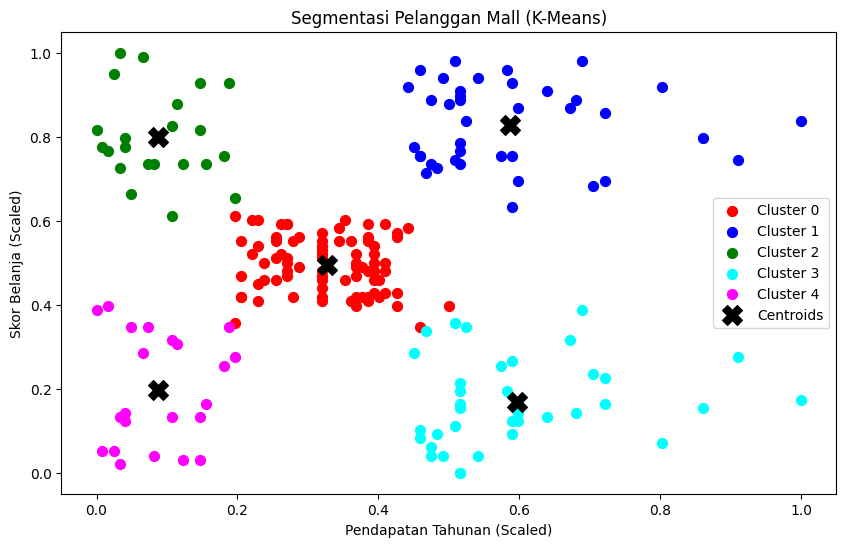


Preview Hasil Clustering:
   CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1                  15                      39        4
1           2                  15                      81        2
2           3                  16                       6        4
3           4                  16                      77        2
4           5                  17                      40        4


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# 1. Load Data
# Pastikan file Mall_Customers.csv sudah di-upload ke Colab
df = pd.read_csv("Mall_Customers.csv")

# 2. Pemilihan Fitur (Feature Selection)
# Kita hanya menggunakan kolom 'Annual Income (k$)' (indeks 3)
# dan 'Spending Score (1-100)' (indeks 4) agar visualisasinya mudah (2D)
X = df.iloc[:, [3, 4]].values

# 3. Normalisasi Data
# Menyamakan skala angka pendapatan dan skor belanja
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 4. Membuat Model K-Means
# Mengelompokkan data menjadi 5 cluster
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Menyimpan hasil kluster ke dalam dataframe asli
df["Cluster"] = y_kmeans

# 5. Visualisasi Hasil Clustering
plt.figure(figsize=(10,6))

# Warna untuk masing-masing kluster
colors = ['red', 'blue', 'green', 'cyan', 'magenta']

# Plot data untuk setiap kluster
for i in range(5):
    plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1],
                s=50, c=colors[i], label=f'Cluster {i}')

# Plot titik Centroid
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')

plt.title('Segmentasi Pelanggan Mall (K-Means)')
plt.xlabel('Pendapatan Tahunan (Scaled)')
plt.ylabel('Skor Belanja (Scaled)')
plt.legend()
plt.show()

# Menampilkan 5 data pertama untuk mengecek hasilnya
print("\nPreview Hasil Clustering:")
print(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head())